In [4]:
# =============================================================================
# CASE STUDY: MULTIPLE LINEAR REGRESSION
# Wheat crop yield (ton/ha) — Biobío Region, Chile
# =============================================================================
# Variables:
#   Y  : Crop yield (ton/ha)                        [response]
#   X1 : Accumulated rainfall during growing cycle (mm)
#   X2 : Mean temperature during flowering stage (°C)
#   X3 : Soil type (1 = Clay-loam, 0 = Sandy)       [dummy]
#   X4 : Nitrogen fertilizer dose applied (kg N/ha)
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('Class 5 - Yield.csv')
df.columns = ['Yield','Rainfall','Temp.','Soil','Fertilizer']
df.head()

,Yield,Rainfall,Temp.,Soil,Fertilizer
0,4.232207,482.398826,17.521954,1,141.229117
1,4.080517,609.157147,19.995429,1,117.025599
2,4.829940,561.038667,18.610855,1,145.734739
3,5.727717,531.704867,15.140541,1,135.914827
4,4.889761,434.324101,14.493981,1,149.855388


In [5]:
df.describe()

,Yield,Rainfall,Temp.,Soil,Fertilizer
count,350.000000,350.000000,350.000000,350.000000,350.000000
mean,3.249173,507.746973,17.471077,0.548571,116.045656
std,1.163626,64.172710,2.090600,0.498348,20.662650
min,0.323076,401.113548,14.075864,0.000000,80.447011
25%,2.444696,452.829588,15.615522,0.000000,97.031670
50%,3.214516,512.124979,17.454659,1.000000,116.616181
75%,4.154705,560.480414,19.284921,1.000000,133.955527
max,5.976311,617.811847,20.998024,1.000000,149.855388


In [6]:
df.corr()

,Yield,Rainfall,Temp.,Soil,Fertilizer
Yield,1.000000,0.453001,-0.274852,0.543449,0.607039
Rainfall,0.453001,1.000000,-0.004045,0.006749,0.047970
Temp.,-0.274852,-0.004045,1.000000,0.057475,-0.000939
Soil,0.543449,0.006749,0.057475,1.000000,0.041160
Fertilizer,0.607039,0.047970,-0.000939,0.041160,1.000000


In [ ]:
# -----------------------------------------------------------------------------
# 2. MODEL FITTING
# -----------------------------------------------------------------------------

X = sm.add_constant(df[['Rainfall','Temp.','Soil','Fertilizer']])
Y = df['Yield']
model = sm.OLS(Y, X).fit()
 
print(model.summary(
    xname=['Intercept', 'Rainfall (X1)', 'Temperature (X2)',
           'Soil type (X3)', 'Fertilizer (X4)'],
    yname='Crop yield (Y)'
))


## Calc. by hand
'''
# -----------------------------------------------------------------------------
# 3. ANOVA TABLE
# -----------------------------------------------------------------------------


SS_reg = model.ess
SS_res = model.ssr
SS_tot = model.centered_tss
df_reg = model.df_model
df_res = model.df_resid
MS_reg = SS_reg / df_reg
MS_res = SS_res / df_res
F_stat = MS_reg / MS_res
p_value_F = model.f_pvalue
F_crit = stats.f.ppf(0.95, df_reg, df_res)

anova_table = pd.DataFrame({
    'Source':    ['Regression', 'Residuals', 'Total'],
    'SS':        [round(SS_reg, 4), round(SS_res, 4), round(SS_tot, 4)],
    'df':        [int(df_reg), int(df_res), int(df_reg + df_res)],
    'MS':        [round(MS_reg, 4), round(MS_res, 4), '—'],
    'F stat':    [round(F_stat, 3), '—', '—'],
    'F crit':    [round(F_crit, 3), '—', '—'],
    'p-value':   [f'{p_value_F:.4f}' if p_value_F >= 0.0001 else '< 0.001', '—', '—']
})
print(anova_table.to_string(index=False))


# -----------------------------------------------------------------------------
# 4. COEFFICIENTS TABLE AND INTERPRETATION
# -----------------------------------------------------------------------------

names = ['Intercept', 'Rainfall (X1)', 'Temperature (X2)',
         'Soil type (X3)', 'Fertilizer (X4)']

coefs_df = pd.DataFrame({
    'Variable':    names,
    'Estimate':    model.params.round(4).values,
    'Std. Error':  model.bse.round(4).values,
    't stat':      model.tvalues.round(3).values,
    'p-value':     [f'{p:.4f}' if p >= 0.0001 else '< 0.001' for p in model.pvalues],
    'CI 95% low':  model.conf_int()[0].round(4).values,
    'CI 95% high': model.conf_int()[1].round(4).values,
})
print(coefs_df.to_string(index=False))
'''

                            OLS Regression Results                            
Dep. Variable:         Crop yield (Y)   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     845.9
Date:                Wed, 01 Apr 2026   Prob (F-statistic):          7.64e-177
Time:                        17:21:55   Log-Likelihood:                -132.63
No. Observations:                 350   AIC:                             275.3
Df Residuals:                     345   BIC:                             294.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -2.0521      0.242  

"\n# -----------------------------------------------------------------------------\n# 3. ANOVA TABLE\n# -----------------------------------------------------------------------------\n\n\nSS_reg = model.ess\nSS_res = model.ssr\nSS_tot = model.centered_tss\ndf_reg = model.df_model\ndf_res = model.df_resid\nMS_reg = SS_reg / df_reg\nMS_res = SS_res / df_res\nF_stat = MS_reg / MS_res\np_value_F = model.f_pvalue\nF_crit = stats.f.ppf(0.95, df_reg, df_res)\n\nanova_table = pd.DataFrame({\n    'Source':    ['Regression', 'Residuals', 'Total'],\n    'SS':        [round(SS_reg, 4), round(SS_res, 4), round(SS_tot, 4)],\n    'df':        [int(df_reg), int(df_res), int(df_reg + df_res)],\n    'MS':        [round(MS_reg, 4), round(MS_res, 4), '—'],\n    'F stat':    [round(F_stat, 3), '—', '—'],\n    'F crit':    [round(F_crit, 3), '—', '—'],\n    'p-value':   [f'{p_value_F:.4f}' if p_value_F >= 0.0001 else '< 0.001', '—', '—']\n})\nprint(anova_table.to_string(index=False))\n\n\n# -----------------

In [8]:
# -----------------------------------------------------------------------------
# 5. GOODNESS OF FIT
# -----------------------------------------------------------------------------
print("\n" + "=" * 65)
print("GOODNESS OF FIT")
print("=" * 65)

r2     = model.rsquared
r2_adj = model.rsquared_adj
rmse   = np.sqrt(model.mse_resid)
resid  = model.resid
mae    = np.mean(np.abs(resid))

print(f"  R²              : {r2:.4f} ")
print(f"  Adjusted R²     : {r2_adj:.4f} ")
print(f"  RMSE            : {rmse:.4f} ton/ha")
print(f"  MAE             : {mae:.4f} ton/ha")




GOODNESS OF FIT
  R²              : 0.9075 
  Adjusted R²     : 0.9064 
  RMSE            : 0.3560 ton/ha
  MAE             : 0.2801 ton/ha


In [9]:
# -----------------------------------------------------------------------------
# 6. ASSUMPTION DIAGNOSTICS
# -----------------------------------------------------------------------------
print("\n" + "=" * 65)
print("ASSUMPTION DIAGNOSTICS")
print("=" * 65)

# [1] Normality — Shapiro-Wilk
stat_sw, p_sw = stats.shapiro(resid)
print(f"\n[1] Normality — Shapiro-Wilk test")
print(f"    W = {stat_sw:.4f},  p-value = {p_sw:.4f}")
print(f"    {'Assumption holds (p > 0.05)' if p_sw > 0.05 else 'Assumption VIOLATED (p <= 0.05)'}")

# [2] Homoscedasticity — Breusch-Pagan
bp_stat, bp_p, _, _ = het_breuschpagan(resid, X)
print(f"\n[2] Homoscedasticity — Breusch-Pagan test")
print(f"    chi2 = {bp_stat:.4f},  p-value = {bp_p:.4f}")
print(f"    {'Assumption holds (p > 0.05)' if bp_p > 0.05 else 'Assumption VIOLATED (p <= 0.05)'}")

# [3] Independence — Durbin-Watson
dw = durbin_watson(resid)
print(f"\n[3] Independence — Durbin-Watson statistic")
print(f"    DW = {dw:.4f}")
print(f"    {'Assumption holds (1.5 < DW < 2.5)' if 1.5 < dw < 2.5 else 'Possible autocorrelation detected'}")

# [4] Multicollinearity

print(f"\n[4] Multicollinearity — Variance Inflation Factors (VIF)")
X_vif = df[['Rainfall','Temp.','Soil','Fertilizer']].copy()

vif_data = pd.DataFrame()
vif_data['Variable'] = ['Rainfall (X1)', 'Temperature (X2)', 'Soil type (X3)', 'Fertilizer (X4)']

vif_data['Aux R²'] = [
    sm.OLS(X_vif.iloc[:, i],
           sm.add_constant(X_vif.drop(X_vif.columns[i], axis=1))).fit().rsquared
    for i in range(4)
]

vif_data['VIF']       = (1 / (1 - vif_data['Aux R²'])).round(4)
vif_data['Tolerance'] = (1 / vif_data['VIF']).round(4)
vif_data['Diagnosis'] = vif_data['VIF'].apply(
    lambda v: 'No problem' if v < 2
    else ('Acceptable' if v < 5
    else ('Moderate'   if v < 10
    else 'SEVERE'))
)

print(vif_data.to_string(index=False))


# [5] Multicollinearity — Condition Number (New version, be careful !!)
print(f"\n[5] Multicollinearity — Condition Number")

X_scaled = (X_vif - X_vif.mean()) / X_vif.std()  # standardize
X_scaled_const = sm.add_constant(X_scaled)

eigenvalues = np.linalg.eigvals(X_scaled_const.T @ X_scaled_const)
condition_number = np.sqrt(eigenvalues.max() / eigenvalues.min())

print(f"    Condition Number = {condition_number:.4f}")

if condition_number < 10:
    print("    No multicollinearity problem (CN < 10)")
elif condition_number < 30:
    print("    Moderate multicollinearity (10 ≤ CN < 30)")
else:
    print("    SEVERE multicollinearity (CN ≥ 30)")



ASSUMPTION DIAGNOSTICS

[1] Normality — Shapiro-Wilk test
    W = 0.9970,  p-value = 0.7603
    Assumption holds (p > 0.05)

[2] Homoscedasticity — Breusch-Pagan test
    chi2 = 5.0864,  p-value = 0.2785
    Assumption holds (p > 0.05)

[3] Independence — Durbin-Watson statistic
    DW = 2.0706
    Assumption holds (1.5 < DW < 2.5)

[4] Multicollinearity — Variance Inflation Factors (VIF)
        Variable   Aux R²    VIF  Tolerance  Diagnosis
   Rainfall (X1) 0.002342 1.0023     0.9977 No problem
Temperature (X2) 0.003333 1.0033     0.9967 No problem
  Soil type (X3) 0.005027 1.0051     0.9949 No problem
 Fertilizer (X4) 0.003978 1.0040     0.9960 No problem

[5] Multicollinearity — Condition Number
    Condition Number = 1.0797
    No multicollinearity problem (CN < 10)


In [10]:
# -----------------------------------------------------------------------------
# 7. PREDICTION WITH CONFIDENCE AND PREDICTION INTERVALS
# -----------------------------------------------------------------------------
print("\n" + "=" * 65)
print("PREDICTION FOR A NEW PLOT")
print("=" * 65)

new_obs = pd.DataFrame({'const': 1, 'X1': 450, 'X2': 17, 'X3': 1, 'X4': 100}, index=[0])
pred    = model.get_prediction(new_obs)
pred_df = pred.summary_frame(alpha=0.05)

print("  Conditions: Rainfall=450 mm, Temp=17°C, Clay-loam soil, Fertilizer=100 kg N/ha")
print(f"  Y-hat (point estimate)         : {pred_df['mean'].values[0]:.4f} ton/ha")
print(f"  95% Confidence interval (mean) : [{pred_df['mean_ci_lower'].values[0]:.4f}, "
      f"{pred_df['mean_ci_upper'].values[0]:.4f}]")
print(f"  95% Prediction interval (obs.) : [{pred_df['obs_ci_lower'].values[0]:.4f}, "
      f"{pred_df['obs_ci_upper'].values[0]:.4f}]")




PREDICTION FOR A NEW PLOT
  Conditions: Rainfall=450 mm, Temp=17°C, Clay-loam soil, Fertilizer=100 kg N/ha
  Y-hat (point estimate)         : 2.9414 ton/ha
  95% Confidence interval (mean) : [2.8731, 3.0096]
  95% Prediction interval (obs.) : [2.2378, 3.6449]


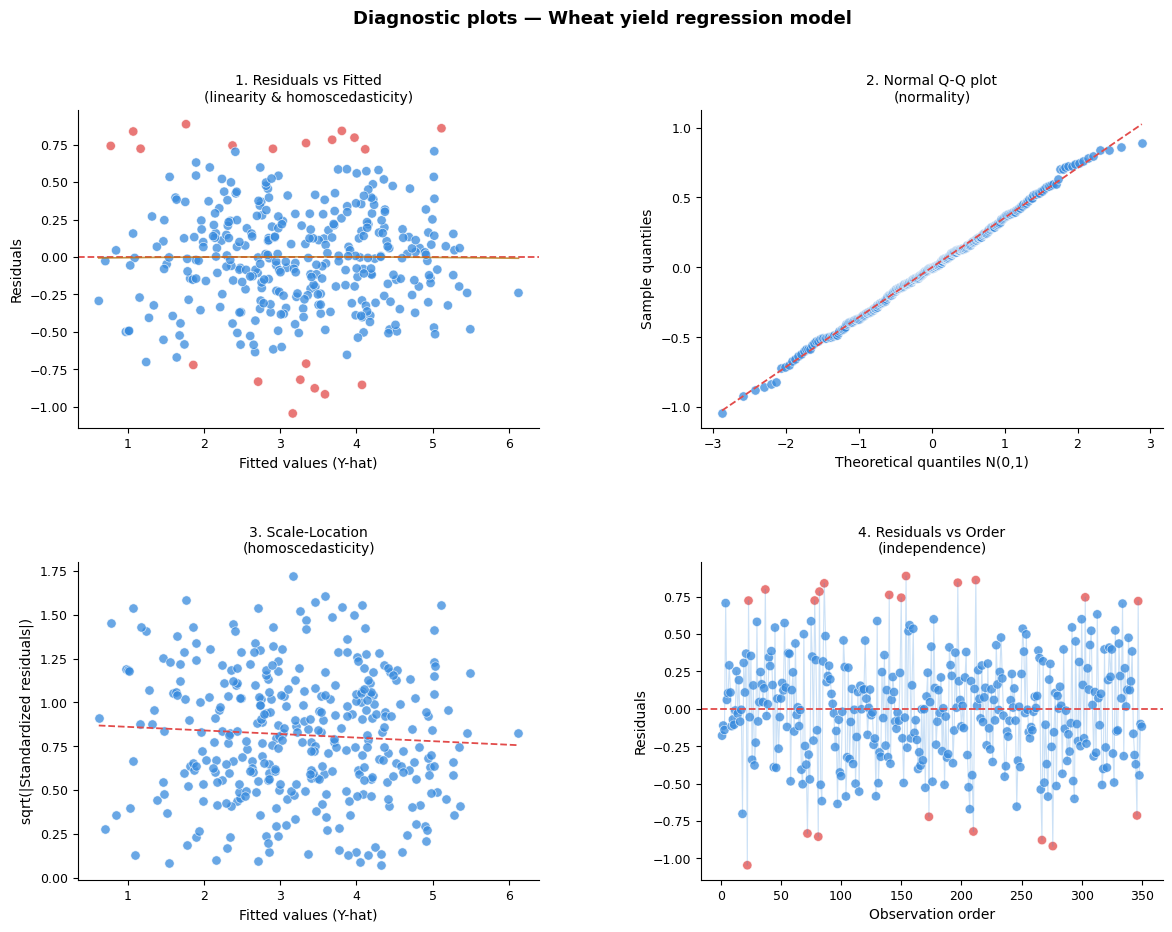

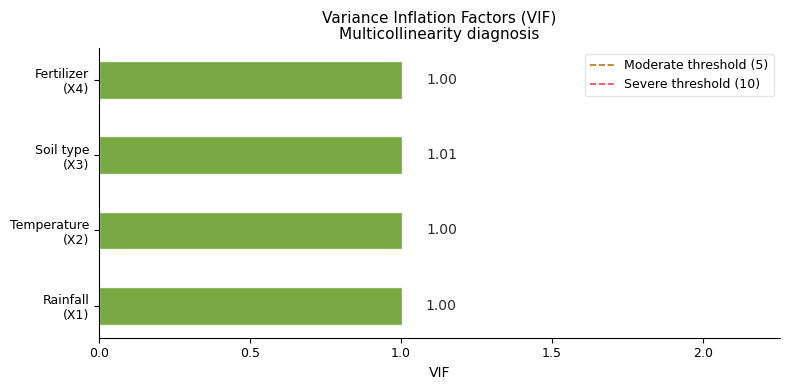

In [11]:
# -----------------------------------------------------------------------------
# 8. DIAGNOSTIC PLOTS
# -----------------------------------------------------------------------------
fitted    = model.fittedvalues
resid     = model.resid
std_resid = model.get_influence().resid_studentized_internal
sqrt_std  = np.sqrt(np.abs(std_resid))

COLOR_PT   = '#378ADD'
COLOR_LINE = '#E24B4A'
COLOR_SMTH = '#BA7517'

fig = plt.figure(figsize=(14, 10))
fig.suptitle('Diagnostic plots — Wheat yield regression model',
             fontsize=13, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(2, 2, hspace=0.42, wspace=0.35)

# --- Plot 1: Residuals vs Fitted ---
ax1 = fig.add_subplot(gs[0, 0])
colors1 = [COLOR_LINE if abs(r) > np.std(resid) * 2 else COLOR_PT for r in resid]
ax1.scatter(fitted, resid, c=colors1, alpha=0.75, s=45, edgecolors='white', linewidth=0.5)
ax1.axhline(0, color=COLOR_LINE, linestyle='--', linewidth=1.3)
xline = np.linspace(fitted.min(), fitted.max(), 200)
z = np.polyfit(fitted, resid, 2)
ax1.plot(xline, np.polyval(z, xline), color=COLOR_SMTH, linewidth=1.2, alpha=0.8)
ax1.set_xlabel('Fitted values (Y-hat)', fontsize=10)
ax1.set_ylabel('Residuals', fontsize=10)
ax1.set_title('1. Residuals vs Fitted\n(linearity & homoscedasticity)', fontsize=10)
ax1.tick_params(labelsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# --- Plot 2: Normal Q-Q ---
ax2 = fig.add_subplot(gs[0, 1])
(osm, osr), (slope, intercept, _) = stats.probplot(resid, dist='norm')
ax2.scatter(osm, osr, c=COLOR_PT, alpha=0.75, s=45, edgecolors='white', linewidth=0.5)
xmin, xmax = min(osm), max(osm)
ax2.plot([xmin, xmax], [slope * xmin + intercept, slope * xmax + intercept],
         color=COLOR_LINE, linestyle='--', linewidth=1.3)
ax2.set_xlabel('Theoretical quantiles N(0,1)', fontsize=10)
ax2.set_ylabel('Sample quantiles', fontsize=10)
ax2.set_title('2. Normal Q-Q plot\n(normality)', fontsize=10)
ax2.tick_params(labelsize=9)
ax2.spines[['top', 'right']].set_visible(False)

# --- Plot 3: Scale-Location ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(fitted, sqrt_std, c=COLOR_PT, alpha=0.75, s=45, edgecolors='white', linewidth=0.5)
z2 = np.polyfit(fitted, sqrt_std, 1)
ax3.plot(xline, np.polyval(z2, xline), color=COLOR_LINE, linestyle='--', linewidth=1.3)
ax3.set_xlabel('Fitted values (Y-hat)', fontsize=10)
ax3.set_ylabel('sqrt(|Standardized residuals|)', fontsize=10)
ax3.set_title('3. Scale-Location\n(homoscedasticity)', fontsize=10)
ax3.tick_params(labelsize=9)
ax3.spines[['top', 'right']].set_visible(False)

# --- Plot 4: Residuals vs Observation Order ---
ax4 = fig.add_subplot(gs[1, 1])
order = np.arange(1, len(df) + 1)
colors4 = [COLOR_LINE if abs(r) > np.std(resid) * 2 else COLOR_PT for r in resid]
ax4.scatter(order, resid, c=colors4, alpha=0.75, s=45, edgecolors='white', linewidth=0.5)
ax4.plot(order, resid, color=COLOR_PT, alpha=0.25, linewidth=0.8)
ax4.axhline(0, color=COLOR_LINE, linestyle='--', linewidth=1.3)
ax4.set_xlabel('Observation order', fontsize=10)
ax4.set_ylabel('Residuals', fontsize=10)
ax4.set_title('4. Residuals vs Order\n(independence)', fontsize=10)
ax4.tick_params(labelsize=9)
ax4.spines[['top', 'right']].set_visible(False)


plt.show()

# --- VIF Bar Chart ---
fig2, ax = plt.subplots(figsize=(8, 4))
var_labels = ['Rainfall\n(X1)', 'Temperature\n(X2)', 'Soil type\n(X3)', 'Fertilizer\n(X4)']
vifs = vif_data['VIF'].values
bar_colors = ['#E24B4A' if v >= 10 else ('#BA7517' if v >= 5 else
              ('#EF9F27' if v >= 2 else '#639922')) for v in vifs]
bars = ax.barh(var_labels, vifs, color=bar_colors, alpha=0.85, height=0.5, edgecolor='white')
ax.axvline(5,  color='#BA7517', linestyle='--', linewidth=1.2, label='Moderate threshold (5)')
ax.axvline(10, color='#E24B4A', linestyle='--', linewidth=1.2, label='Severe threshold (10)')
for bar, v in zip(bars, vifs):
    ax.text(v + 0.08, bar.get_y() + bar.get_height() / 2,
            f'{v:.2f}', va='center', fontsize=10, color='#2C2C2A')
ax.set_xlabel('VIF', fontsize=10)
ax.set_title('Variance Inflation Factors (VIF)\nMulticollinearity diagnosis', fontsize=11)
ax.set_xlim(0, max(vifs) * 1.25 + 1)
ax.legend(fontsize=9, framealpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9)
plt.tight_layout()

plt.show()


In [12]:
# -----------------------------------------------------------------------------
# EXPLANATION vs PREDICTION — Two uses of the same model
# -----------------------------------------------------------------------------
print("=" * 65)
print("EXPLANATION — What drives wheat yield?")
print("=" * 65)

names = ['Intercept', 'Rainfall (X1)', 'Temperature (X2)',
         'Soil type (X3)', 'Fertilizer (X4)']

for name, coef, pval, ci_low, ci_high in zip(
        names[1:],
        model.params[1:],
        model.pvalues[1:],
        model.conf_int()[0][1:],
        model.conf_int()[1][1:]):
    sig = "✔ significant" if pval < 0.05 else "✘ not significant"
    print(f"\n  {name}")
    print(f"    β = {coef:.4f}  →  holding all else constant, a 1-unit")
    print(f"        increase in this variable changes yield by {coef:.4f} ton/ha")
    print(f"    95% CI: [{ci_low:.4f}, {ci_high:.4f}]")
    print(f"    p-value: {pval:.4f}  ({sig})")

print("\n\n" + "=" * 65)
print("PREDICTION — What yield do we expect for a new plot?")
print("=" * 65)

scenarios = pd.DataFrame({
    'const': 1,
    'X1': [450, 500, 400],
    'X2': [17,  15,  19],
    'X3': [1,   1,   0],
    'X4': [100, 120, 80]
})

labels = ['Favorable conditions',
          'Optimal conditions',
          'Adverse conditions']

for i, label in enumerate(labels):
    pred = model.get_prediction(scenarios.iloc[[i]])
    pf   = pred.summary_frame(alpha=0.05)
    print(f"\n  Scenario: {label}")
    print(f"    Conditions : X1={scenarios.iloc[i]['X1']} mm, "
          f"X2={scenarios.iloc[i]['X2']}°C, "
          f"X3={'Clay-loam' if scenarios.iloc[i]['X3']==1 else 'Sandy'}, "
          f"X4={scenarios.iloc[i]['X4']} kg N/ha")
    print(f"    Point estimate     : {pf['mean'].values[0]:.4f} ton/ha")
    print(f"    95% CI (mean)      : [{pf['mean_ci_lower'].values[0]:.4f}, "
          f"{pf['mean_ci_upper'].values[0]:.4f}]")
    print(f"    95% PI (new obs.)  : [{pf['obs_ci_lower'].values[0]:.4f}, "
          f"{pf['obs_ci_upper'].values[0]:.4f}]")
    print(f"    PI width           : "
          f"{pf['obs_ci_upper'].values[0] - pf['obs_ci_lower'].values[0]:.4f} ton/ha")

EXPLANATION — What drives wheat yield?

  Rainfall (X1)
    β = 0.0076  →  holding all else constant, a 1-unit
        increase in this variable changes yield by 0.0076 ton/ha
    95% CI: [0.0071, 0.0082]
    p-value: 0.0000  (✔ significant)

  Temperature (X2)
    β = -0.1688  →  holding all else constant, a 1-unit
        increase in this variable changes yield by -0.1688 ton/ha
    95% CI: [-0.1868, -0.1509]
    p-value: 0.0000  (✔ significant)

  Soil type (X3)
    β = 1.2488  →  holding all else constant, a 1-unit
        increase in this variable changes yield by 1.2488 ton/ha
    95% CI: [1.1734, 1.3242]
    p-value: 0.0000  (✔ significant)

  Fertilizer (X4)
    β = 0.0318  →  holding all else constant, a 1-unit
        increase in this variable changes yield by 0.0318 ton/ha
    95% CI: [0.0300, 0.0336]
    p-value: 0.0000  (✔ significant)


PREDICTION — What yield do we expect for a new plot?

  Scenario: Favorable conditions
    Conditions : X1=450 mm, X2=17°C, X3=Clay-loam,

In [13]:
# -----------------------------------------------------------------------------
# EXPLANATION vs PREDICTION — A good explanatory model is not always
# a good predictive model
# -----------------------------------------------------------------------------
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error

print("=" * 65)
print("EXPLANATION vs PREDICTION")
print("=" * 65)

# --- Split data 70/30 ---
X_full = sm.add_constant(df[['Rainfall','Temp.','Soil','Fertilizer']])
y_full = df['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.30, random_state=42)

# --- Fit on training set only ---
model_train = sm.OLS(y_train, X_train).fit()

# --- In-sample metrics (explanation) ---
y_hat_train = model_train.fittedvalues
rmse_train  = np.sqrt(mean_squared_error(y_train, y_hat_train))
mae_train   = np.mean(np.abs(y_train - y_hat_train))
r2_train    = model_train.rsquared

# --- Out-of-sample metrics (prediction) ---
y_hat_test  = model_train.predict(X_test)
rmse_test   = np.sqrt(mean_squared_error(y_test, y_hat_test))
mae_test    = np.mean(np.abs(y_test - y_hat_test))
ss_res_test = np.sum((y_test - y_hat_test) ** 2)
ss_tot_test = np.sum((y_test - y_test.mean()) ** 2)
r2_test     = 1 - ss_res_test / ss_tot_test

print(f"\n{'Metric':<25} {'Train (explanation)':>20} {'Test (prediction)':>20}")
print("-" * 65)
print(f"{'R²':<25} {r2_train:>20.4f} {r2_test:>20.4f}")
print(f"{'RMSE (ton/ha)':<25} {rmse_train:>20.4f} {rmse_test:>20.4f}")
print(f"{'MAE  (ton/ha)':<25} {mae_train:>20.4f} {mae_test:>20.4f}")
print("-" * 65)
print(f"\n  R² drop  : {r2_train - r2_test:+.4f}")
print(f"  RMSE rise: {rmse_test - rmse_train:+.4f} ton/ha")

# --- Cross-validation for a more robust estimate ---
print("\n" + "=" * 65)
print("5-FOLD CROSS VALIDATION — Predictive performance")
print("=" * 65)

from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_np = df[['Rainfall','Temp.','Soil','Fertilizer']].values
y_np = df['Yield'].values

rmse_folds, mae_folds, r2_folds = [], [], []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_np), 1):
    lr = LinearRegression().fit(X_np[train_idx], y_np[train_idx])
    y_pred_fold = lr.predict(X_np[test_idx])
    rmse_folds.append(np.sqrt(mean_squared_error(y_np[test_idx], y_pred_fold)))
    mae_folds.append(np.mean(np.abs(y_np[test_idx] - y_pred_fold)))
    ss_r = np.sum((y_np[test_idx] - y_pred_fold) ** 2)
    ss_t = np.sum((y_np[test_idx] - y_np[test_idx].mean()) ** 2)
    r2_folds.append(1 - ss_r / ss_t)
    print(f"  Fold {fold}: RMSE = {rmse_folds[-1]:.4f}  "
          f"MAE = {mae_folds[-1]:.4f}  R² = {r2_folds[-1]:.4f}")

print("-" * 65)
print(f"  Mean   : RMSE = {np.mean(rmse_folds):.4f}  "
      f"MAE = {np.mean(mae_folds):.4f}  R² = {np.mean(r2_folds):.4f}")
print(f"  Std Dev: RMSE = {np.std(rmse_folds):.4f}  "
      f"MAE = {np.std(mae_folds):.4f}  R² = {np.std(r2_folds):.4f}")

EXPLANATION vs PREDICTION

Metric                     Train (explanation)    Test (prediction)
-----------------------------------------------------------------
R²                                      0.9079               0.9033
RMSE (ton/ha)                           0.3570               0.3491
MAE  (ton/ha)                           0.2811               0.2837
-----------------------------------------------------------------

  R² drop  : +0.0046
  RMSE rise: -0.0079 ton/ha

5-FOLD CROSS VALIDATION — Predictive performance
  Fold 1: RMSE = 0.3250  MAE = 0.2645  R² = 0.9158
  Fold 2: RMSE = 0.3842  MAE = 0.3077  R² = 0.8985
  Fold 3: RMSE = 0.3534  MAE = 0.2676  R² = 0.9057
  Fold 4: RMSE = 0.3647  MAE = 0.2968  R² = 0.9041
  Fold 5: RMSE = 0.3608  MAE = 0.2851  R² = 0.8976
-----------------------------------------------------------------
  Mean   : RMSE = 0.3576  MAE = 0.2843  R² = 0.9043
  Std Dev: RMSE = 0.0192  MAE = 0.0166  R² = 0.0065
